# TP 3 : CNN - Convolution et Pooling

Ce TP explore comment les convolutions permettent d'extraire les caractéristiques essentielles d'une image et comment le pooling réduit la complexité des données tout en conservant les informations importantes.

**1. Introduction et Visualisation de l'Image**

Une convolution est un filtre qui passe sur une image pour en extraire les caractéristiques importantes. Pour qu'un programme puisse "voir" un objet (comme une chaussure), il doit isoler les fonctionnalités utiles et ignorer le bruit.

**Étape 1 : Chargement des bibliothèques et de l'image**

Nous utilisons l'image "ascent" de SciPy, qui contient de nombreux angles et lignes idéaux pour tester les filtres.

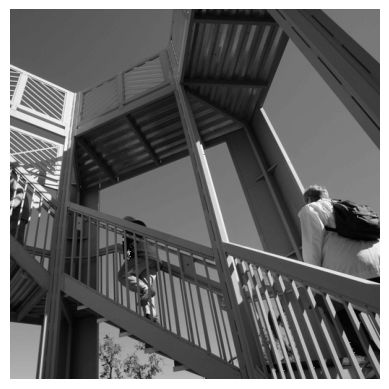

In [1]:
import cv2
import numpy as np
from scipy import datasets
import matplotlib.pyplot as plt

# Chargement de l'image de test
i = datasets.ascent()

# Affichage de l'image originale
plt.grid(False)
plt.gray()
plt.axis('off')
plt.imshow(i)
plt.show()

# Stockage des dimensions et création d'une copie pour la transformation
i_transformed = np.copy(i)
size_x = i_transformed.shape[0]
size_y = i_transformed.shape[1]

**2. Le Processus de Convolution**

Le principe est de scanner chaque pixel de l'image et de regarder ses voisins. On multiplie la valeur de chaque pixel voisin par un poids équivalent dans une matrice appelée filtre.

**Étape 2 : Définition du filtre et application**

Le code suivant parcourt l'image en laissant une marge de 1 pixel et applique une matrice 3x3.

In [4]:
# Définition d'un filtre 3x3
# On utilise une liste standard ou un tableau numpy float pour éviter l'overflow
filtre = [ [0, 1, 0], [1, -4, 1], [0, 1, 0]]

poids = 1.0

# Itération sur l'image (en laissant une marge de 1 pixel)
for x in range(1, size_x - 1):
    for y in range(1, size_y - 1):
        # IMPORTANT : On force la conversion en float() pour chaque pixel
        # lors du calcul pour éviter l'erreur "uint8 out of bounds"
        out = 0.0
        out = out + (float(i[x-1, y-1]) * filtre[0][0])
        out = out + (float(i[x, y-1])   * filtre[0][1])
        out = out + (float(i[x+1, y-1]) * filtre[0][2])
        out = out + (float(i[x-1, y])   * filtre[1][0])
        out = out + (float(i[x, y])     * filtre[1][1])
        out = out + (float(i[x+1, y])   * filtre[1][2])
        out = out + (float(i[x-1, y+1]) * filtre[2][0])
        out = out + (float(i[x, y+1])   * filtre[2][1])
        out = out + (float(i[x+1, y+1]) * filtre[2][2])

        out = out * poids

        # On applique les seuils AVANT de stocker dans l'image finale [cite: 62, 83, 85]
        if(out < 0): out = 0
        if(out > 255): out = 255

        i_transformed[x, y] = out

**Étape 3 : Affichage du résultat de la convolution**

L'image résultante (carte des caractéristiques) met en évidence les lignes et les structures isolées par le filtre.

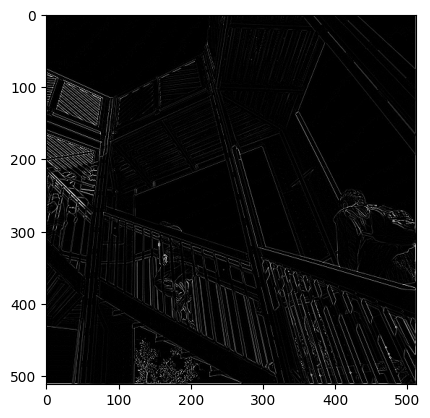

In [5]:
plt.gray()
plt.grid(False)
plt.imshow(i_transformed)
plt.show()

**3. Comprendre le Pooling**

La mise en commun (pooling) réduit la quantité globale d'informations tout en conservant les caractéristiques détectées.

**Étape 4 : Application du Max Pooling (2, 2)**

On parcourt l'image par blocs de 2x2 pixels et on ne garde que la valeur maximale de chaque bloc. L'image finale fera un quart de la taille d'origine (la moitié en largeur et la moitié en hauteur).

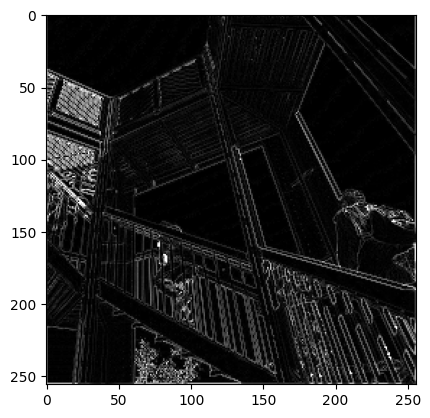

Dimensions après pooling : (256, 256)


In [6]:
# Nouvelles dimensions (512x512 -> 256x256) [cite: 136, 137]
new_x = int(size_x / 2)
new_y = int(size_y / 2)
newImage = np.zeros((new_x, new_y))

# Parcours avec un pas (stride) de 2
for x in range(0, size_x, 2):
    for y in range(0, size_y, 2):
        # On récupère les 4 pixels voisins
        pixels = []
        pixels.append(i_transformed[x, y])
        pixels.append(i_transformed[x+1, y])
        pixels.append(i_transformed[x, y+1])
        pixels.append(i_transformed[x+1, y+1])

        # On garde la valeur maximale (Max Pooling) [cite: 141, 142]
        pixels.sort(reverse=True)
        newImage[int(x/2), int(y/2)] = pixels[0]

# Affichage du résultat final
plt.gray()
plt.grid(False)
plt.imshow(newImage)
plt.show()

print(f"Dimensions après pooling : {newImage.shape}") # Devrait afficher (256, 256)

**Conclusion**

L'image finale est plus petite (256x256), mais les caractéristiques détectées ont été améliorées et préservées malgré la réduction de données.